# TORA Benchmark

This benchmark considers translational oscillations by a rotational actuator (TORA). A cart is attached to a wall with a spring and is free to move on a frictionless surface. The cart has a weight attached to an arm inside it, which is free to rotate about an axis. This serves as the control input to stabilize the cart at $x = 0$.

This benchmark is taken from the ARCH-COMP25 Category Report: Artificial Intelligence and Neural Network Control Systems (AINNCS) for Continuous and Hybrid Systems Plants.

In [5]:
import argparse
import jax
import jax.numpy as jnp
import immrax as irx
from time import time

parser = argparse.ArgumentParser()
parser.add_argument('--plot', action='store_true', help='save reach-set plot (tora-relu_tanh.png/.pdf)')
args, _ = parser.parse_known_args()

## TORA Dynamics and Controller

The model is a four-dimensional system, given by the following equations:

$$
\begin{aligned}
\dot{x}_1 &= x_2 \\
\dot{x}_2 &= -x_1 + 0.1 \sin(x_3) \\
\dot{x}_3 &= x_4 \\
\dot{x}_4 &= u
\end{aligned}
$$

The selected controller has three hidden layers of 20 neurons each and one output layer, using sigmoid activation functions for the hidden layers and a tanh output layer. The output of the neural network $f(x)$ is post-processed as $u = 11 \cdot f(x)$.

In [6]:
class TORA (irx.System) :
    def __init__(self) -> None:
        self.evolution = 'continuous'
        self.xlen = 4
    def f(self, t:jnp.ndarray, x:jnp.ndarray, u:jnp.ndarray, w:jnp.ndarray) -> jnp.ndarray :
        return jnp.array([
            x[1],
            -x[0] + 0.1*jnp.sin(x[2]),
            x[3],
            u[0]
        ])

olsys = TORA()
# net = irx.NeuralNetwork('models/controllerTora')
net = irx.NeuralNetwork('models/nn_tora_relu_tanh')
# net = irx.NeuralNetwork('models/nn_tora_sigmoid')
clsys = irx.NNCSystem(olsys, net)

print(net.seq[-1].weight, net.seq[-1].bias)

Successfully loaded model from models/nn_tora_relu_tanh/model.eqx
[[11.]] [0.]


## Specification

The initial set is
$$
x \in [-0.77, -0.75] \times [-0.45, -0.43] \times [0.51, 0.54] \times [-0.3, -0.28]
$$

The specification requires that the system reaches the set $x_1 \in [-0.1, 0.2]$, $x_2 \in [-0.9, -0.6]$ within a time window of 5 s.

In [7]:
perm = irx.standard_permutation(1+4+1+1)[0]
# ix0 = irx.interval(jnp.array([0.6, -0.7, -0.4, 0.5]), jnp.array([0.7, -0.6, -0.3, 0.6]))
ix0 = irx.interval(jnp.array([-0.77, -0.45, 0.51, -0.3]), jnp.array([-0.75, -0.43, 0.54, -0.28]))
cent, pert = irx.i2centpert(ix0)
# ix0 = irx.icentpert(cent, 0.25*pert)
pt0 = irx.Polytope.from_interval(ix0)

t0 = 0.
tf = 5.
# tf = 20.
dt = 0.05
max_steps = round ((tf - t0) / dt)

goal = irx.interval([-0.1, -0.9], [0.2, -0.6])
goal_check = irx.interval([-0.1, -0.9, -jnp.inf, -jnp.inf], [0.2, -0.6, jnp.inf, jnp.inf])

## Reachability Analysis

We compute the reachable set using `FastlinAdjointEmbedding`.

In [8]:
w_map = lambda t, x : irx.izeros(1)

@jax.jit
def jit_reach_set(t0, dt, tf, pt0) :
    fae = irx.FastlinAdjointEmbedding(clsys, jnp.eye(4), jnp.zeros((0,4)), perm)
    RS = fae.compute_reachset(t0, tf, pt0, (w_map,), dt, solver='tsit5')
    yy = RS.ys[0]
    aux = RS.ys[1]

    last = max_steps
    ixT = irx.interval(aux[0][last]) @ irx.interval(-yy.y[last][:4], yy.y[last][4:]) + yy.ox[last]
    
    return RS, irx.utils.check_containment(ixT, goal_check)

# JIT Compile
jit_t0 = time()
_ = jax.block_until_ready(jit_reach_set(0., dt, dt, pt0))
jit_tf = time()
print(f'JIT compiled in {jit_tf - jit_t0:.5f} seconds')

/tmp/claude-1000/ipykernel_1747106/1169812571.py:5: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  fae = irx.FastlinAdjointEmbedding(clsys, jnp.eye(4), jnp.zeros((0,4)), perm)


JIT compiled in 6.37353 seconds


In [9]:
# ix0 = irx.icentpert(cent, pert*10)
# pt0 = irx.Polytope.from_interval(ix0)

N = 10
(RS, S), times = irx.utils.run_times(N, jit_reach_set, t0, dt, tf, pt0)
print(f'Computed Reachable Set in {jnp.mean(times):.5f} ± {jnp.std(times):.5f} over {N} runs')

runtime = jnp.mean(times)

if S == 1 :
    status = 'VERIFIED'
elif S == 0 :
    status = 'UNKNOWN' 
else :
    status = 'VIOLATED'

print(f'TORA,reach-tanh,{status},{runtime},comment')

Computed Reachable Set in 0.05341 ± 0.01105 over 10 runs
TORA,reach-tanh,VERIFIED,0.05341479182243347,comment


## Plotting

Saved tora-relu_tanh.{png,pdf}


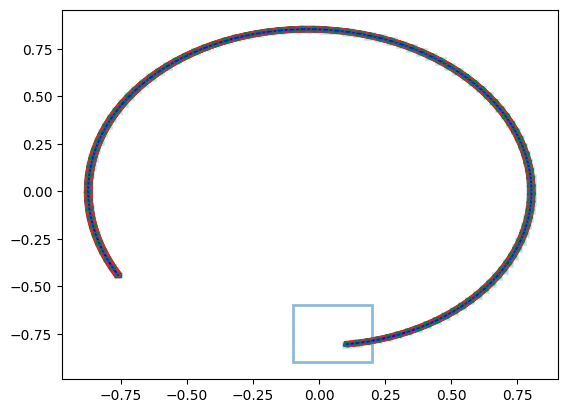

In [10]:
if args.plot:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    yy = RS.ys[0]
    tfinite = jnp.where(jnp.isfinite(RS.ts))
    tt = RS.ts[tfinite]
    aux = RS.ys[1]

    fig, ax = plt.subplots()

    PLOT_EVERY = 1

    # Goal
    irx.utils.draw_iarray(ax, goal, c='tab:green', alpha=0.5)

    # Nominal trajectories first so the reach-set tube draws on top
    ax.plot(yy.ox[tfinite][:,0], yy.ox[tfinite][:,1], c='blue', zorder=1)

    def mc_wmap (t, x) :
        return jnp.array([0.])
    for mc_x0 in irx.utils.gen_ics(ix0, 100) :
        mc_traj = clsys.compute_trajectory(t0,tf,mc_x0,(mc_wmap,),dt,solver='tsit5')
        mc_finite = jnp.where(jnp.isfinite(mc_traj.ts))
        if PLOT_EVERY == 1:
            ax.plot(mc_traj.ys[mc_finite][:,0], mc_traj.ys[mc_finite][:,1], color='tab:red', zorder=0)
        else :
            ax.scatter(mc_traj.ys[mc_finite][::PLOT_EVERY,0], mc_traj.ys[mc_finite][::PLOT_EVERY,1], color='tab:red', zorder=0, s=1)

    # Reach-set tube on top
    for i in range(0,len(tt),PLOT_EVERY) :
        pti = pt0.__class__.from_parametope(irx.hParametope(yy.ox[i], yy.alpha[i,:], yy.y[i,:]))
        ixi = irx.interval(aux[0][i]) @ irx.interval(-yy.y[i][:4], yy.y[i][4:]) + yy.ox[i]
        irx.utils.draw_iarray(
            ax, irx.interval(ixi.lower[:2], ixi.upper[:2]),
            ec='tab:blue', fc='tab:blue', alpha=0.2, zorder=2,
        )
        try :
            pti.plot_projection(ax)
        except Exception:
            pass

    fig.savefig('tora-relu_tanh.png', dpi=300)
    fig.savefig('tora-relu_tanh.pdf')
    print('Saved tora-relu_tanh.{png,pdf}')